Files already downloaded and verified


D:\CODE\Thesis\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Files already downloaded and verified
Train samples: 50000
Test samples:  10000
Image shape:   (32, 32, 3)  dtype=uint8
Num classes:   100


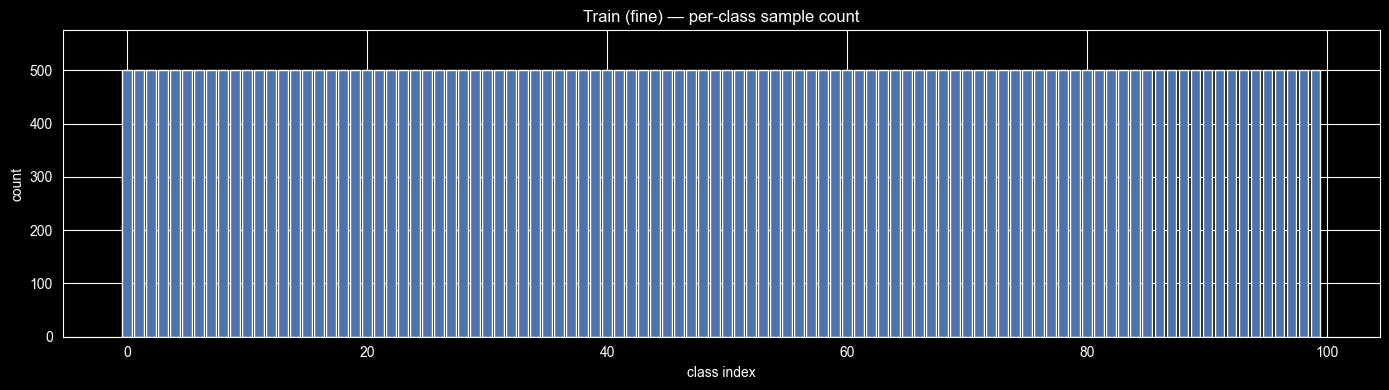

Train (fine): min=500, max=500, mean=500.0, std=0.000


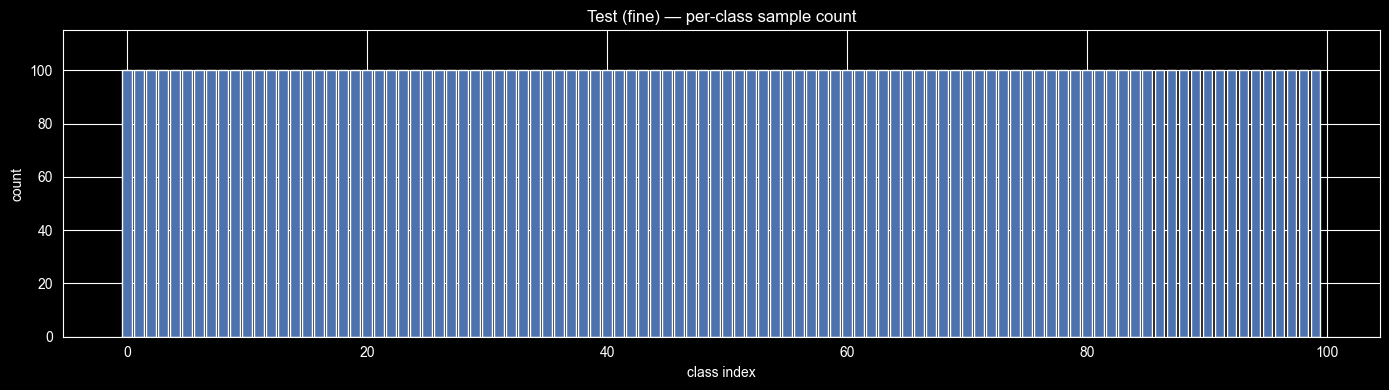

Test (fine): min=100, max=100, mean=100.0, std=0.000


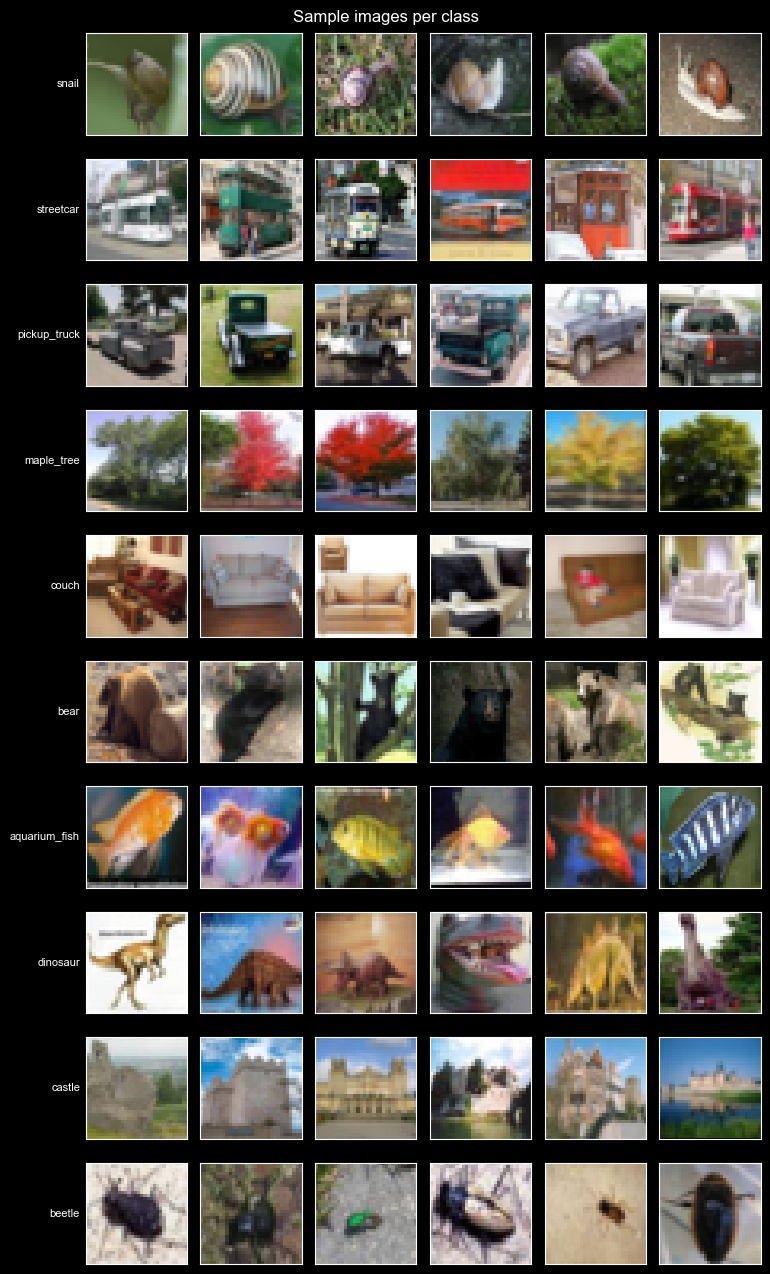

Train channel mean (RGB): [0.5070754  0.48655024 0.44091907]
Train channel std  (RGB): [0.26733398 0.25643876 0.2761503 ]
Test channel mean (RGB): [0.508796   0.4873928  0.44194147]
Test channel std  (RGB): [0.26825172 0.25736356 0.27709562]


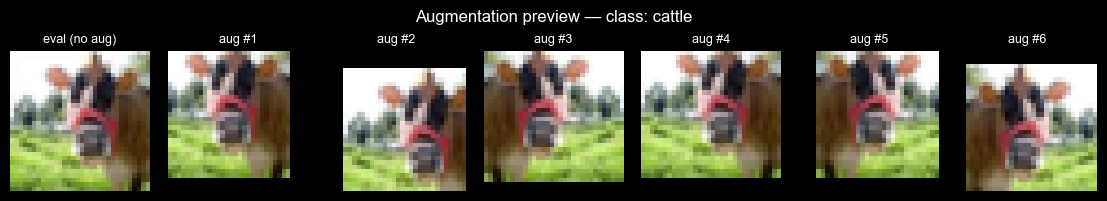

C:\Users\adnan\AppData\Local\Temp\ipykernel_18796\1064470643.py:147: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding="latin1")


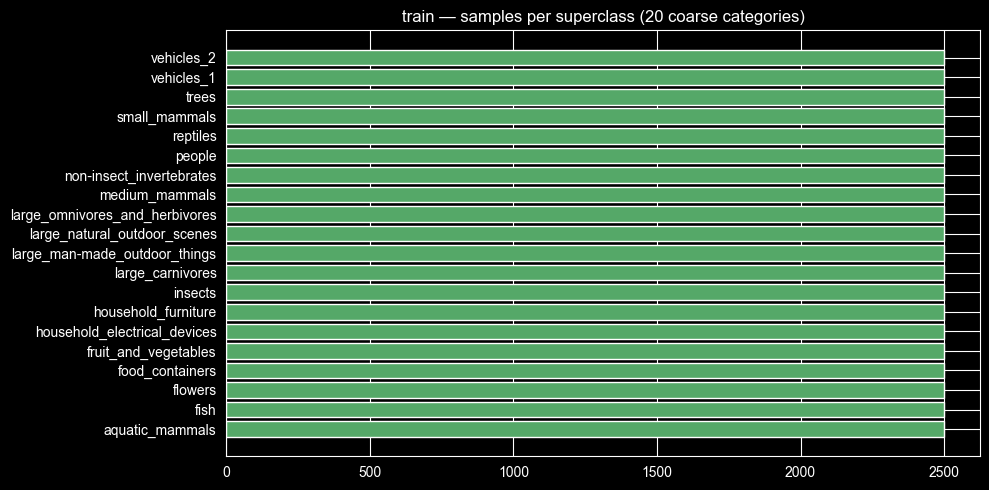

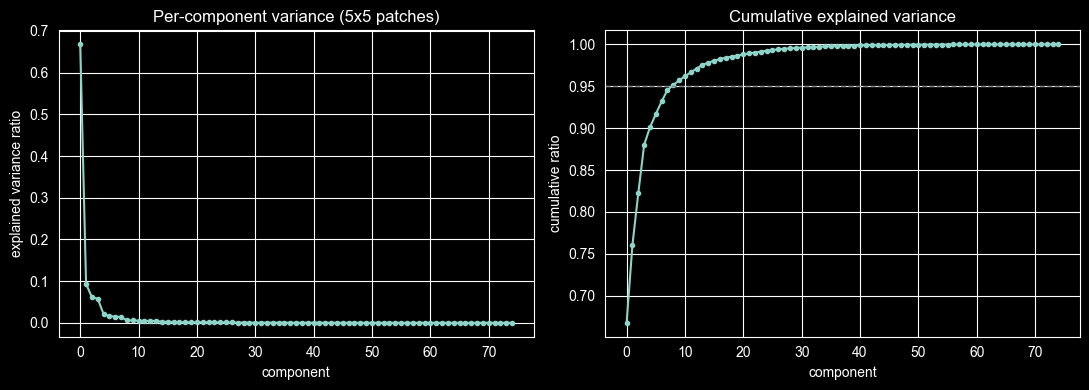

Components needed for 95% variance: 9 / 75


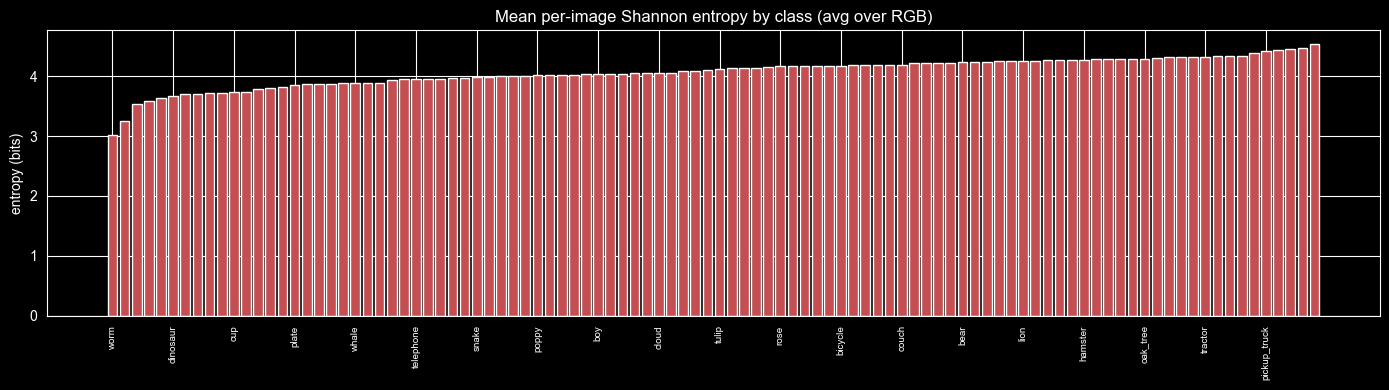

Entropy range across classes: 3.02 - 4.54 bits (spread: 1.52)


In [1]:
"""
CIFAR-100 Exploratory Data Analysis
------------------------------------

All plots are saved to ./eda_outputs/ as PNGs in addition to being shown,
"""

import os
import pickle
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "eda_outputs"
os.makedirs(OUT_DIR, exist_ok=True)


# ---------------------------------------------------------------------------
# 1. Basic shape / size info
# ---------------------------------------------------------------------------
def basic_info(train_ds, test_ds):
    print(f"Train samples: {len(train_ds)}")
    print(f"Test samples:  {len(test_ds)}")
    print(f"Image shape:   {train_ds.data.shape[1:]}  dtype={train_ds.data.dtype}")
    print(f"Num classes:   {len(train_ds.classes)}")
    return train_ds.data.shape


# ---------------------------------------------------------------------------
# 2. Class balance (fine labels). CIFAR-100 is balanced by construction
#    (500/class train, 100/class test)
# ---------------------------------------------------------------------------
def class_distribution(ds, title, fname):
    counts = Counter(ds.targets)
    counts_sorted = [counts[i] for i in range(len(ds.classes))]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(len(counts_sorted)), counts_sorted, color="#4C72B0")
    ax.set_title(f"{title} — per-class sample count")
    ax.set_xlabel("class index")
    ax.set_ylabel("count")
    ax.set_ylim(0, max(counts_sorted) * 1.15)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=150)
    plt.show()
    print(f"{title}: min={min(counts_sorted)}, max={max(counts_sorted)}, "
          f"mean={np.mean(counts_sorted):.1f}, std={np.std(counts_sorted):.3f}")


# ---------------------------------------------------------------------------
# 3. Sample grid across random classes (raw pixels, no transform applied)
# ---------------------------------------------------------------------------
def sample_grid(ds, n_classes=10, per_class=6, seed=0):
    rng = np.random.default_rng(seed)
    class_ids = rng.choice(len(ds.classes), size=n_classes, replace=False)
    targets = np.array(ds.targets)
    fig, axes = plt.subplots(n_classes, per_class,
                              figsize=(per_class * 1.3, n_classes * 1.3))
    if n_classes == 1:
        axes = axes[None, :]
    for row, cid in enumerate(class_ids):
        idxs = np.where(targets == cid)[0]
        chosen = rng.choice(idxs, size=per_class, replace=False)
        for col, idx in enumerate(chosen):
            axes[row, col].imshow(ds.data[idx])
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            if col == 0:
                axes[row, col].set_ylabel(ds.classes[cid], rotation=0,
                                           ha="right", va="center", fontsize=8)
    plt.suptitle("Sample images per class")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "sample_grid.png"), dpi=150)
    plt.show()


# ---------------------------------------------------------------------------
# 4. Per-channel pixel statistics — the numbers you'd plug into Normalize(),
#    and a scale sanity check for the PCA stage (PCA is scale-sensitive).
# ---------------------------------------------------------------------------
def pixel_stats(ds, name):
    data = ds.data.astype(np.float32) / 255.0  # N,H,W,C
    mean = data.mean(axis=(0, 1, 2))
    std = data.std(axis=(0, 1, 2))
    print(f"{name} channel mean (RGB): {mean}")
    print(f"{name} channel std  (RGB): {std}")
    return mean, std


# ---------------------------------------------------------------------------
# 5. Augmentation preview — same index through train_full_aug multiple times
#    vs. the untouched eval version, so you can eyeball how aggressive the
#    aug pipeline is before it feeds into training.
# ---------------------------------------------------------------------------
def _to_display(img_tensor):
    """Best-effort un-normalize + CHW->HWC for plotting."""
    img = img_tensor.detach().cpu().numpy()
    if img.ndim == 3 and img.shape[0] in (1, 3):
        img = np.transpose(img, (1, 2, 0))
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    return img


def augmentation_preview(aug_ds, eval_ds, idx=0, n_views=6):
    fig, axes = plt.subplots(1, n_views + 1, figsize=((n_views + 1) * 1.6, 2))
    eval_img, label = eval_ds[idx]
    axes[0].imshow(_to_display(eval_img))
    axes[0].set_title("eval (no aug)", fontsize=9)
    axes[0].axis("off")
    for i in range(n_views):
        aug_img, _ = aug_ds[idx]
        axes[i + 1].imshow(_to_display(aug_img))
        axes[i + 1].set_title(f"aug #{i+1}", fontsize=9)
        axes[i + 1].axis("off")
    plt.suptitle(f"Augmentation preview — class: {eval_ds.classes[label]}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "augmentation_preview.png"), dpi=150)
    plt.show()


# ---------------------------------------------------------------------------
# 6. Superclass structure (CIFAR-100's 20 coarse categories, 5 fine classes
#    each). torchvision's CIFAR100 only exposes fine labels, so this reads
#    the raw pickle directly. Skips gracefully if not found.
# ---------------------------------------------------------------------------
def superclass_breakdown(data_root, split="train"):
    base = os.path.join(data_root, "cifar-100-python")
    fpath = os.path.join(base, split)
    meta_path = os.path.join(base, "meta")
    if not (os.path.exists(fpath) and os.path.exists(meta_path)):
        print("Raw pickle files not found at expected path — skipping superclass breakdown.")
        return None
    with open(fpath, "rb") as f:
        d = pickle.load(f, encoding="latin1")
    with open(meta_path, "rb") as f:
        meta = pickle.load(f, encoding="latin1")
    coarse_labels = np.array(d["coarse_labels"])
    coarse_names = meta["coarse_label_names"]
    counts = Counter(coarse_labels)
    order = sorted(counts.keys())
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh([coarse_names[i] for i in order], [counts[i] for i in order], color="#55A868")
    ax.set_title(f"{split} — samples per superclass (20 coarse categories)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"superclass_{split}.png"), dpi=150)
    plt.show()
    return coarse_labels, coarse_names


# ---------------------------------------------------------------------------
# 7. Patch-level PCA eigenvalue spectrum — directly relevant to a PCANet-
#    style filter bank (5x5 patches as fixed conv filters). Tells you how
#    many principal components you actually need to capture the local
#    structure your first PCA stage is trying to summarize.
# ---------------------------------------------------------------------------
def patch_pca_spectrum(ds, patch_size=5, n_images=1500, stride=2, seed=0):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(ds.data), size=min(n_images, len(ds.data)), replace=False)
    patches = []
    for idx in idxs:
        img = ds.data[idx].astype(np.float32) / 255.0  # HWC
        H, W, C = img.shape
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                patches.append(img[y:y + patch_size, x:x + patch_size, :].reshape(-1))
    patches = np.stack(patches)
    patches = patches - patches.mean(axis=0, keepdims=True)
    cov = np.cov(patches, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)[::-1]
    eigvals = np.clip(eigvals, 0, None)
    explained = eigvals / eigvals.sum()
    cum_explained = np.cumsum(explained)

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(explained, marker="o", ms=3)
    ax[0].set_title(f"Per-component variance ({patch_size}x{patch_size} patches)")
    ax[0].set_xlabel("component")
    ax[0].set_ylabel("explained variance ratio")
    ax[1].plot(cum_explained, marker="o", ms=3)
    ax[1].axhline(0.95, color="gray", linestyle="--", linewidth=1)
    ax[1].set_title("Cumulative explained variance")
    ax[1].set_xlabel("component")
    ax[1].set_ylabel("cumulative ratio")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "patch_pca_spectrum.png"), dpi=150)
    plt.show()

    n95 = int(np.searchsorted(cum_explained, 0.95) + 1)
    print(f"Components needed for 95% variance: {n95} / {patches.shape[1]}")
    return eigvals


# ---------------------------------------------------------------------------
# 8. Per-channel Shannon entropy by class — relevant to IG-Dropout, which
#    scores channels by entropy. Checks whether entropy varies a lot across
#    classes (i.e. whether a fixed threshold generalizes, or should adapt).
# ---------------------------------------------------------------------------
def channel_entropy(img, bins=32):
    ents = []
    for c in range(img.shape[2]):
        hist, _ = np.histogram(img[:, :, c], bins=bins, range=(0, 255))
        prob = hist / hist.sum()
        prob = prob[prob > 0]
        ents.append(-np.sum(prob * np.log2(prob)))
    return ents


def entropy_by_class(ds, n_per_class=20, seed=0):
    rng = np.random.default_rng(seed)
    targets = np.array(ds.targets)
    class_mean_entropy = []
    for c in range(len(ds.classes)):
        idxs = np.where(targets == c)[0]
        if len(idxs) == 0:
            class_mean_entropy.append([np.nan, np.nan, np.nan])
            continue
        chosen = rng.choice(idxs, size=min(n_per_class, len(idxs)), replace=False)
        ents = [channel_entropy(ds.data[i]) for i in chosen]
        class_mean_entropy.append(np.mean(ents, axis=0))
    class_mean_entropy = np.array(class_mean_entropy)  # (n_classes, 3)

    n_classes = len(ds.classes)
    order = np.argsort(class_mean_entropy.mean(axis=1))
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(n_classes), class_mean_entropy.mean(axis=1)[order], color="#C44E52")
    step = max(1, n_classes // 20)
    ax.set_xticks(range(0, n_classes, step))
    ax.set_xticklabels([ds.classes[order[i]] for i in range(0, n_classes, step)],
                        rotation=90, fontsize=7)
    ax.set_title("Mean per-image Shannon entropy by class (avg over RGB)")
    ax.set_ylabel("entropy (bits)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "entropy_by_class.png"), dpi=150)
    plt.show()

    valid = ~np.isnan(class_mean_entropy.mean(axis=1))
    m = class_mean_entropy.mean(axis=1)[valid]
    print(f"Entropy range across classes: {m.min():.2f} - {m.max():.2f} bits "
          f"(spread: {m.max() - m.min():.2f})")
    return class_mean_entropy


# ---------------------------------------------------------------------------
# Run everything
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    # Point these at your actual objects/paths before running as a script.
    from torchvision import datasets, transforms

    DATA_ROOT = "./data"
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ])
    eval_transform = transforms.Compose([transforms.ToTensor()])

    train_full_aug = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True,
                                        transform=train_transform)
    train_full_eval = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True,
                                         transform=eval_transform)
    test_ds = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True,
                                 transform=eval_transform)

    basic_info(train_full_eval, test_ds)
    class_distribution(train_full_eval, "Train (fine)", "class_dist_train.png")
    class_distribution(test_ds, "Test (fine)", "class_dist_test.png")
    sample_grid(train_full_eval)
    pixel_stats(train_full_eval, "Train")
    pixel_stats(test_ds, "Test")
    augmentation_preview(train_full_aug, train_full_eval, idx=0)
    superclass_breakdown(DATA_ROOT, "train")
    patch_pca_spectrum(train_full_eval, patch_size=5)
    entropy_by_class(train_full_eval)

Train samples: 1020
Val samples:   1020
Test samples:  6149
Num classes:   102
train: example image #0 shape = (500, 754, 3) (images vary in size — see image_size_distribution)
val: example image #0 shape = (500, 606, 3) (images vary in size — see image_size_distribution)
test: example image #0 shape = (500, 523, 3) (images vary in size — see image_size_distribution)


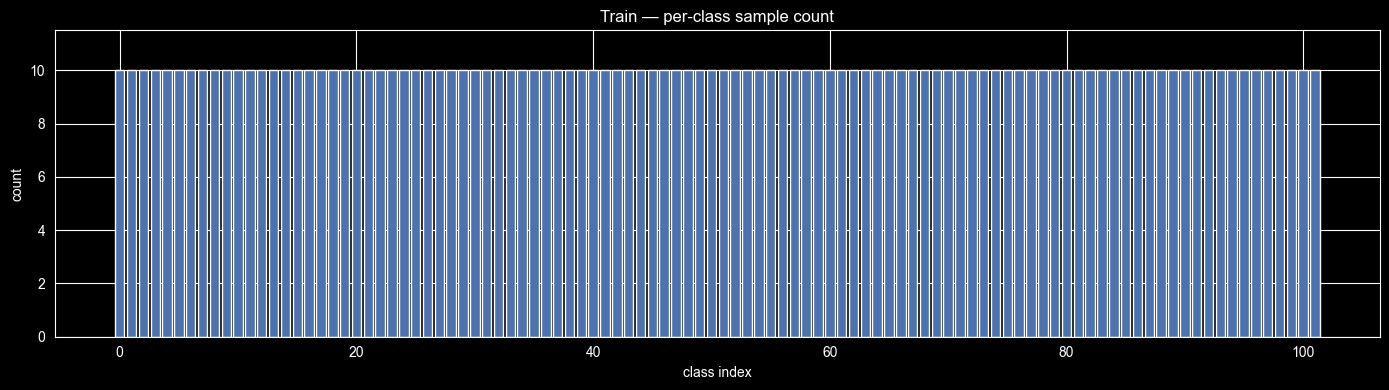

Train: min=10, max=10, mean=10.0, std=0.000


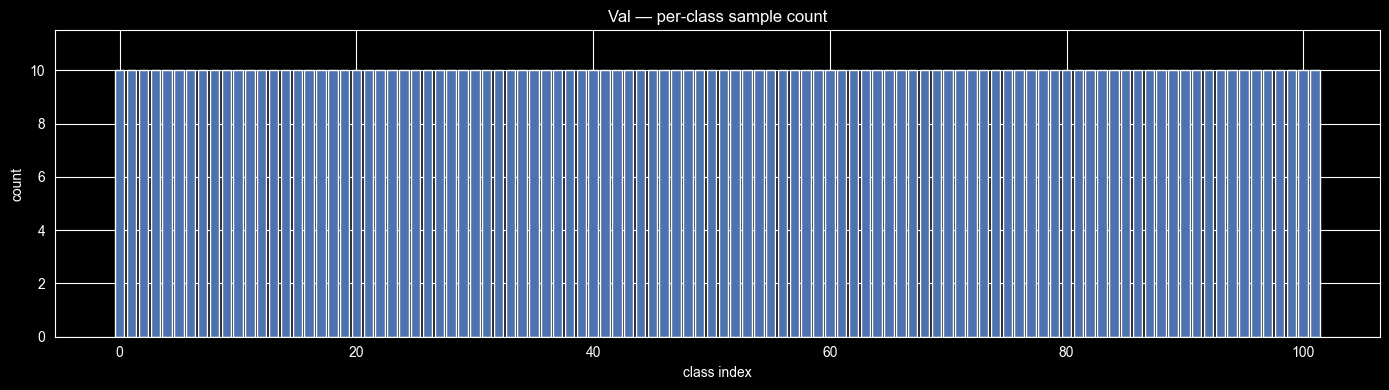

Val: min=10, max=10, mean=10.0, std=0.000


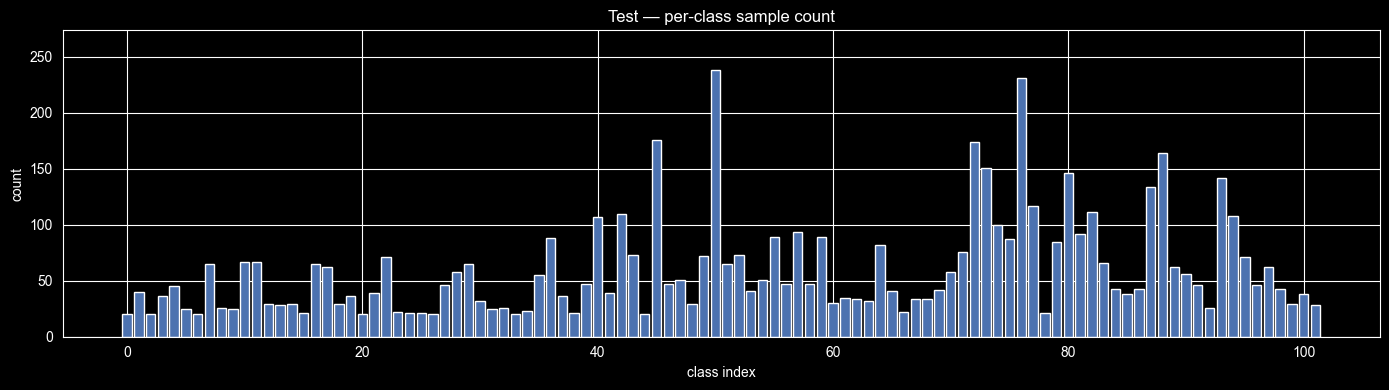

Test: min=20, max=238, mean=60.3, std=44.059


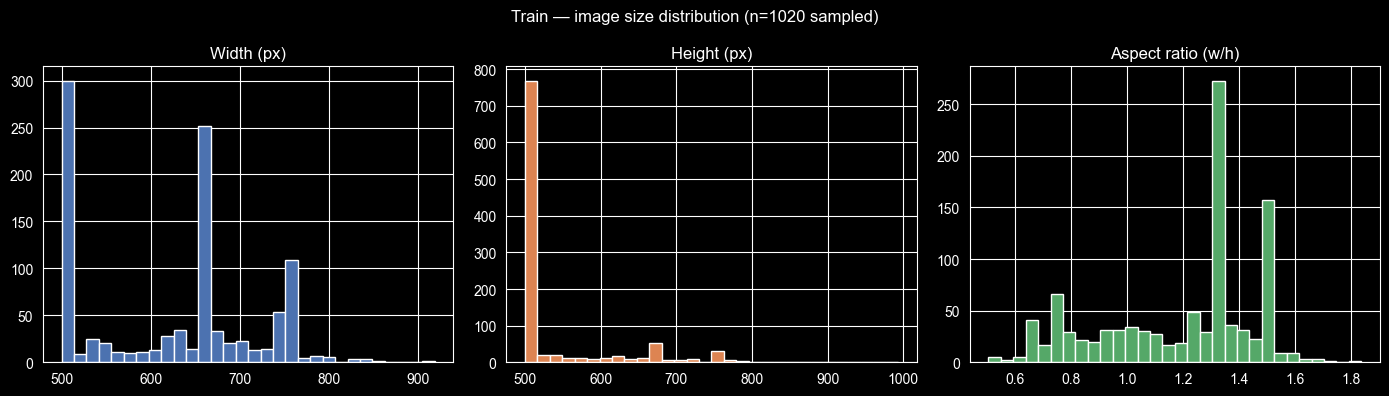

Train width:  min=500, median=666, max=919
Train height: min=500, median=500, max=993
Train aspect ratio: min=0.50, median=1.33, max=1.84


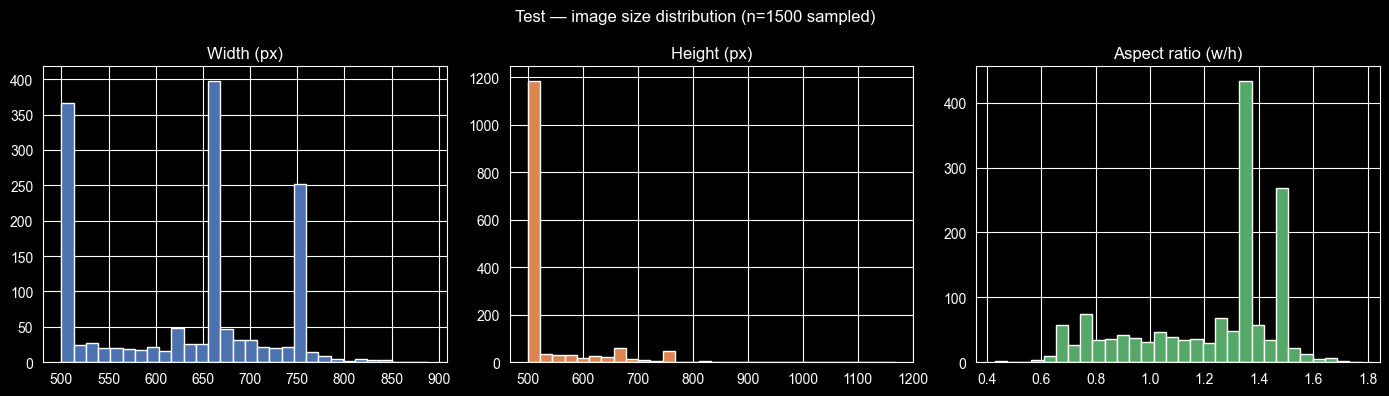

Test width:  min=500, median=667, max=889
Test height: min=500, median=500, max=1168
Test aspect ratio: min=0.43, median=1.33, max=1.78


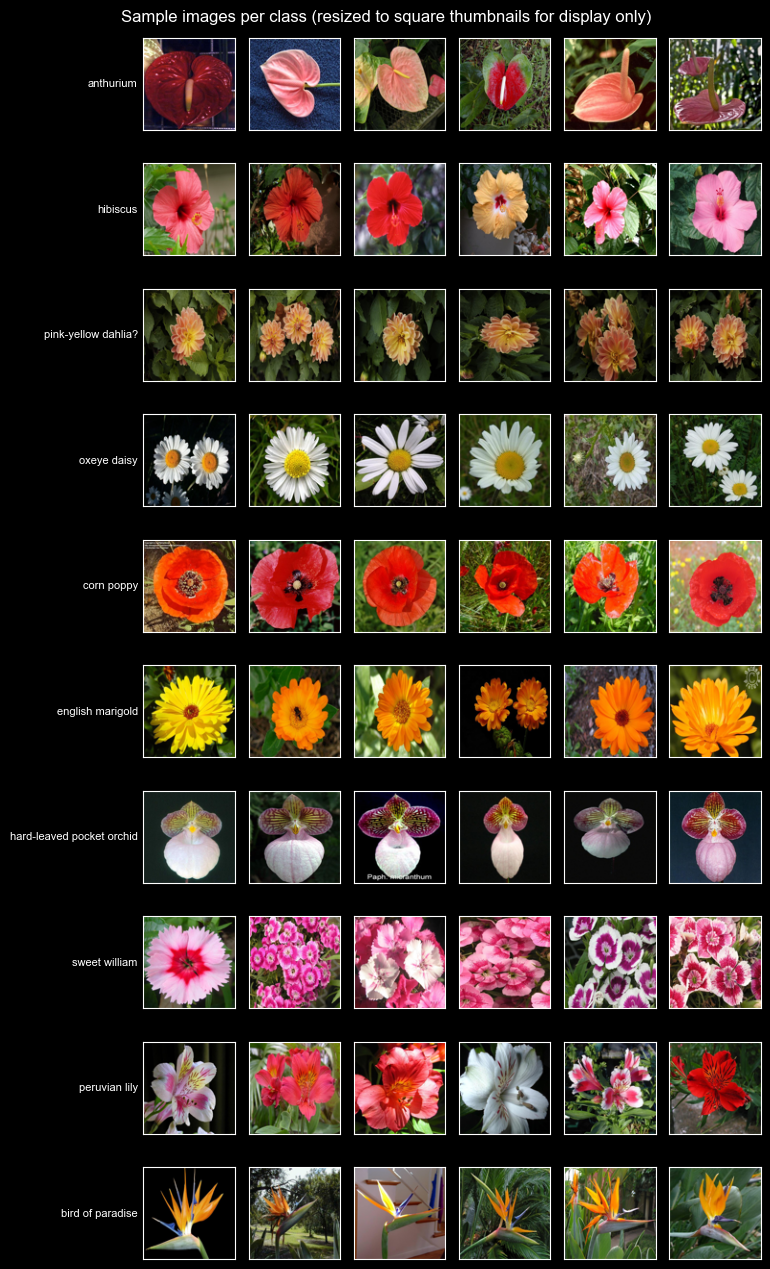

Train channel mean (RGB), n=1020 images: [0.43019177 0.37963086 0.29456918]
Train channel std  (RGB), n=1020 images: [0.29450594 0.24642625 0.27318045]


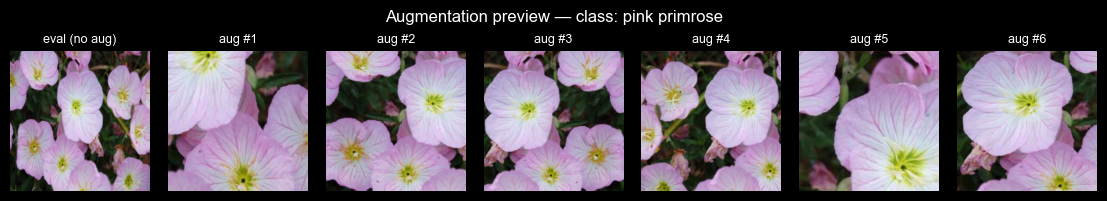

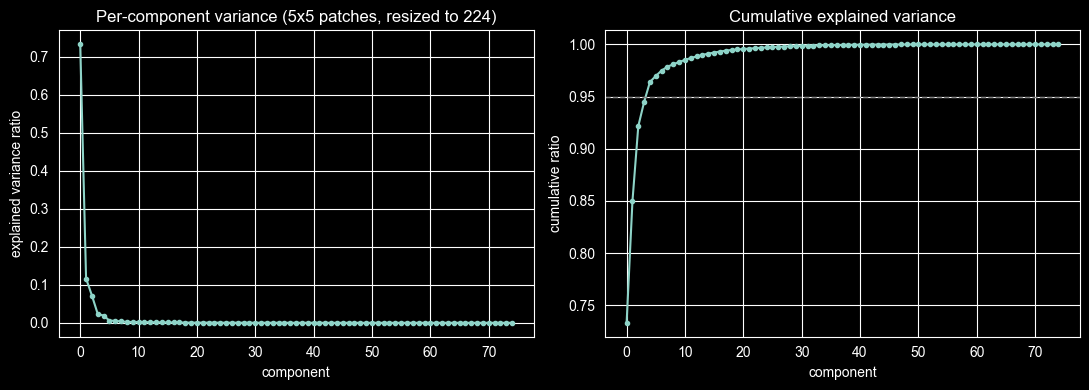

Components needed for 95% variance: 5 / 75


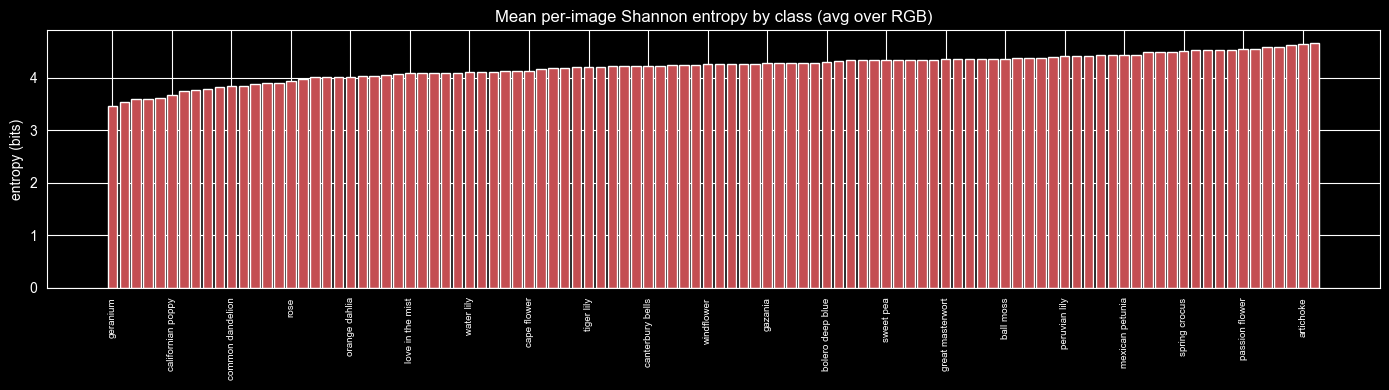

Entropy range across classes: 3.46 - 4.67 bits (spread: 1.21)


In [3]:
"""
Flowers102 Exploratory Data Analysis
-------------------------------------
Builds on top of the dataset objects you already create:

Flowers102 is structurally very different from CIFAR-100 and the EDA has to
account for that:

  - No in-memory `.data` array — images live on disk as JPEGs of VARYING
    resolution, loaded lazily via PIL. Everything below reads from disk.
  - `ds.classes` (102 flower names) only exists from torchvision 0.22.0
    onward — older versions don't set it at all, which is what caused the
    AttributeError. `_get_classes()` below falls back to a hardcoded copy
    of the same 102 names so this runs on any torchvision version.
  - The per-sample labels/file paths (`_labels`, `_image_files`) are private
    attributes of torchvision's implementation — used here because there's
    no public equivalent, but worth knowing if a future torchvision version
    renames them.
  - The official splits are NOT balanced the way CIFAR's are: train = 1020
    images (exactly 10/class), val = 1020 (exactly 10/class), test = 6149
    images with natural class imbalance (originally 40-258 images/class
    total, most of which land in test). That imbalance is worth confirming
    directly rather than assuming, since it affects how you read test
    accuracy per-class.
  - Needs `scipy` installed (torchvision uses it to read the .mat label/
    split files).

Figures save to ./eda_outputs/ as PNGs.
"""

import os
from collections import Counter

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

OUT_DIR = "eda_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Fallback for torchvision < 0.22.0, where Flowers102 doesn't set .classes
# at all. Same 102 names torchvision itself uses on newer versions.
_FLOWERS102_CLASSES = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells", "sweet pea",
    "english marigold", "tiger lily", "moon orchid", "bird of paradise", "monkshood",
    "globe thistle", "snapdragon", "colt's foot", "king protea", "spear thistle",
    "yellow iris", "globe-flower", "purple coneflower", "peruvian lily",
    "balloon flower", "giant white arum lily", "fire lily", "pincushion flower",
    "fritillary", "red ginger", "grape hyacinth", "corn poppy",
    "prince of wales feathers", "stemless gentian", "artichoke", "sweet william",
    "carnation", "garden phlox", "love in the mist", "mexican aster",
    "alpine sea holly", "ruby-lipped cattleya", "cape flower", "great masterwort",
    "siam tulip", "lenten rose", "barbeton daisy", "daffodil", "sword lily",
    "poinsettia", "bolero deep blue", "wallflower", "marigold", "buttercup",
    "oxeye daisy", "common dandelion", "petunia", "wild pansy", "primula",
    "sunflower", "pelargonium", "bishop of llandaff", "gaura", "geranium",
    "orange dahlia", "pink-yellow dahlia?", "cautleya spicata", "japanese anemone",
    "black-eyed susan", "silverbush", "californian poppy", "osteospermum",
    "spring crocus", "bearded iris", "windflower", "tree poppy", "gazania",
    "azalea", "water lily", "rose", "thorn apple", "morning glory",
    "passion flower", "lotus", "toad lily", "anthurium", "frangipani", "clematis",
    "hibiscus", "columbine", "desert-rose", "tree mallow", "magnolia", "cyclamen",
    "watercress", "canna lily", "hippeastrum", "bee balm", "ball moss", "foxglove",
    "bougainvillea", "camellia", "mallow", "mexican petunia", "bromelia",
    "blanket flower", "trumpet creeper", "blackberry lily",
]


# ---------------------------------------------------------------------------
# Small helpers to reach into the dataset regardless of its storage format
# ---------------------------------------------------------------------------
def _get_labels(ds):
    return np.array(ds._labels)


def _get_image_path(ds, idx):
    return ds._image_files[idx]


def _get_classes(ds):
    return getattr(ds, "classes", _FLOWERS102_CLASSES)


def _load_image_array(path):
    return np.array(Image.open(path).convert("RGB"))


# ---------------------------------------------------------------------------
# 1. Basic info
# ---------------------------------------------------------------------------
def basic_info(train_ds, val_ds, test_ds):
    print(f"Train samples: {len(train_ds)}")
    print(f"Val samples:   {len(val_ds)}")
    print(f"Test samples:  {len(test_ds)}")
    print(f"Num classes:   {len(_get_classes(train_ds))}")
    for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
        img0 = _load_image_array(_get_image_path(ds, 0))
        print(f"{name}: example image #0 shape = {img0.shape} (images vary in size — see image_size_distribution)")


# ---------------------------------------------------------------------------
# 2. Class balance — confirms the train/val (balanced) vs test (imbalanced)
#    split structure rather than assuming it.
# ---------------------------------------------------------------------------
def class_distribution(ds, title, fname):
    labels = _get_labels(ds)
    counts = Counter(labels)
    n_classes = len(_get_classes(ds))
    counts_sorted = [counts.get(i, 0) for i in range(n_classes)]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(n_classes), counts_sorted, color="#4C72B0")
    ax.set_title(f"{title} — per-class sample count")
    ax.set_xlabel("class index")
    ax.set_ylabel("count")
    ax.set_ylim(0, max(counts_sorted) * 1.15)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=150)
    plt.show()
    print(f"{title}: min={min(counts_sorted)}, max={max(counts_sorted)}, "
          f"mean={np.mean(counts_sorted):.1f}, std={np.std(counts_sorted):.3f}")


# ---------------------------------------------------------------------------
# 3. Image size distribution — the key thing CIFAR-100 didn't need. Directly
#    informs the Resize/CenterCrop target in train_transform / eval_transform.
# ---------------------------------------------------------------------------
def image_size_distribution(ds, title, max_images=1500, seed=0):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(ds), size=min(max_images, len(ds)), replace=False)
    widths, heights = [], []
    for idx in idxs:
        with Image.open(_get_image_path(ds, idx)) as img:
            w, h = img.size
        widths.append(w)
        heights.append(h)
    widths = np.array(widths)
    heights = np.array(heights)
    aspect = widths / heights

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].hist(widths, bins=30, color="#4C72B0")
    axes[0].set_title("Width (px)")
    axes[1].hist(heights, bins=30, color="#DD8452")
    axes[1].set_title("Height (px)")
    axes[2].hist(aspect, bins=30, color="#55A868")
    axes[2].set_title("Aspect ratio (w/h)")
    plt.suptitle(f"{title} — image size distribution (n={len(idxs)} sampled)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"size_dist_{title.lower()}.png"), dpi=150)
    plt.show()

    print(f"{title} width:  min={widths.min()}, median={int(np.median(widths))}, max={widths.max()}")
    print(f"{title} height: min={heights.min()}, median={int(np.median(heights))}, max={heights.max()}")
    print(f"{title} aspect ratio: min={aspect.min():.2f}, median={np.median(aspect):.2f}, max={aspect.max():.2f}")
    return widths, heights


# ---------------------------------------------------------------------------
# 4. Sample grid — thumbnails resized only for display, not for analysis.
# ---------------------------------------------------------------------------
def sample_grid(ds, n_classes=10, per_class=6, thumb_size=96, seed=0):
    rng = np.random.default_rng(seed)
    labels = _get_labels(ds)
    classes = _get_classes(ds)
    class_ids = rng.choice(len(classes), size=n_classes, replace=False)
    fig, axes = plt.subplots(n_classes, per_class,
                              figsize=(per_class * 1.3, n_classes * 1.3))
    if n_classes == 1:
        axes = axes[None, :]
    for row, cid in enumerate(class_ids):
        idxs = np.where(labels == cid)[0]
        chosen = rng.choice(idxs, size=min(per_class, len(idxs)), replace=False)
        for col in range(per_class):
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            if col < len(chosen):
                with Image.open(_get_image_path(ds, chosen[col])) as img:
                    thumb = img.convert("RGB").resize((thumb_size, thumb_size))
                axes[row, col].imshow(thumb)
            if col == 0:
                axes[row, col].set_ylabel(classes[cid], rotation=0,
                                           ha="right", va="center", fontsize=8)
    plt.suptitle("Sample images per class (resized to square thumbnails for display only)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "sample_grid.png"), dpi=150)
    plt.show()


# ---------------------------------------------------------------------------
# 5. Per-channel pixel statistics — accumulated across all pixels rather
#    than averaged per-image, since images differ in pixel count.
# ---------------------------------------------------------------------------
def pixel_stats(ds, name, max_images=1500, seed=0):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(ds), size=min(max_images, len(ds)), replace=False)
    pixel_sum = np.zeros(3, dtype=np.float64)
    pixel_sq_sum = np.zeros(3, dtype=np.float64)
    pixel_count = 0
    for idx in idxs:
        img = _load_image_array(_get_image_path(ds, idx)).astype(np.float64) / 255.0
        pixel_sum += img.sum(axis=(0, 1))
        pixel_sq_sum += (img ** 2).sum(axis=(0, 1))
        pixel_count += img.shape[0] * img.shape[1]
    mean = pixel_sum / pixel_count
    var = pixel_sq_sum / pixel_count - mean ** 2
    std = np.sqrt(np.clip(var, 0, None))
    print(f"{name} channel mean (RGB), n={len(idxs)} images: {mean}")
    print(f"{name} channel std  (RGB), n={len(idxs)} images: {std}")
    return mean, std


# ---------------------------------------------------------------------------
# 6. Augmentation preview — unchanged in spirit from the CIFAR-100 version.
# ---------------------------------------------------------------------------
def _to_display(img_tensor):
    img = img_tensor.detach().cpu().numpy()
    if img.ndim == 3 and img.shape[0] in (1, 3):
        img = np.transpose(img, (1, 2, 0))
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    return img


def augmentation_preview(aug_ds, eval_ds, idx=0, n_views=6):
    fig, axes = plt.subplots(1, n_views + 1, figsize=((n_views + 1) * 1.6, 2))
    eval_img, label = eval_ds[idx]
    axes[0].imshow(_to_display(eval_img))
    axes[0].set_title("eval (no aug)", fontsize=9)
    axes[0].axis("off")
    for i in range(n_views):
        aug_img, _ = aug_ds[idx]
        axes[i + 1].imshow(_to_display(aug_img))
        axes[i + 1].set_title(f"aug #{i+1}", fontsize=9)
        axes[i + 1].axis("off")
    plt.suptitle(f"Augmentation preview — class: {_get_classes(eval_ds)[label]}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "augmentation_preview.png"), dpi=150)
    plt.show()


# ---------------------------------------------------------------------------
# 7. Patch-level PCA eigenvalue spectrum — relevant to the PCA-ResNet-18
#    pipeline's PCA stage. Images are resized to a fixed size first so
#    patches are comparable across samples; set resize_to to match whatever
#    size your actual pipeline feeds the PCA stage.
# ---------------------------------------------------------------------------
def patch_pca_spectrum(ds, patch_size=5, n_images=800, stride=2, resize_to=224, seed=0):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(ds), size=min(n_images, len(ds)), replace=False)
    patches = []
    for idx in idxs:
        with Image.open(_get_image_path(ds, idx)) as img:
            img = img.convert("RGB").resize((resize_to, resize_to))
            arr = np.array(img).astype(np.float32) / 255.0
        H, W, C = arr.shape
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                patches.append(arr[y:y + patch_size, x:x + patch_size, :].reshape(-1))
    patches = np.stack(patches)
    patches = patches - patches.mean(axis=0, keepdims=True)
    cov = np.cov(patches, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)[::-1]
    eigvals = np.clip(eigvals, 0, None)
    explained = eigvals / eigvals.sum()
    cum_explained = np.cumsum(explained)

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(explained, marker="o", ms=3)
    ax[0].set_title(f"Per-component variance ({patch_size}x{patch_size} patches, resized to {resize_to})")
    ax[0].set_xlabel("component")
    ax[0].set_ylabel("explained variance ratio")
    ax[1].plot(cum_explained, marker="o", ms=3)
    ax[1].axhline(0.95, color="gray", linestyle="--", linewidth=1)
    ax[1].set_title("Cumulative explained variance")
    ax[1].set_xlabel("component")
    ax[1].set_ylabel("cumulative ratio")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "patch_pca_spectrum.png"), dpi=150)
    plt.show()

    n95 = int(np.searchsorted(cum_explained, 0.95) + 1)
    print(f"Components needed for 95% variance: {n95} / {patches.shape[1]}")
    return eigvals


# ---------------------------------------------------------------------------
# 8. Per-channel Shannon entropy by class — same rationale as the CIFAR-100
#    version (checks whether IG-Dropout's entropy threshold should adapt
#    across classes). Uses the resized image so it's comparable across
#    samples of different native resolution.
# ---------------------------------------------------------------------------
def channel_entropy(img, bins=32):
    ents = []
    for c in range(img.shape[2]):
        hist, _ = np.histogram(img[:, :, c], bins=bins, range=(0, 255))
        prob = hist / hist.sum()
        prob = prob[prob > 0]
        ents.append(-np.sum(prob * np.log2(prob)))
    return ents


def entropy_by_class(ds, n_per_class=10, resize_to=224, seed=0):
    rng = np.random.default_rng(seed)
    labels = _get_labels(ds)
    classes = _get_classes(ds)
    n_classes = len(classes)
    class_mean_entropy = []
    for c in range(n_classes):
        idxs = np.where(labels == c)[0]
        if len(idxs) == 0:
            class_mean_entropy.append([np.nan, np.nan, np.nan])
            continue
        chosen = rng.choice(idxs, size=min(n_per_class, len(idxs)), replace=False)
        ents = []
        for i in chosen:
            with Image.open(_get_image_path(ds, i)) as img:
                arr = np.array(img.convert("RGB").resize((resize_to, resize_to)))
            ents.append(channel_entropy(arr))
        class_mean_entropy.append(np.mean(ents, axis=0))
    class_mean_entropy = np.array(class_mean_entropy)

    order = np.argsort(class_mean_entropy.mean(axis=1))
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(n_classes), class_mean_entropy.mean(axis=1)[order], color="#C44E52")
    step = max(1, n_classes // 20)
    ax.set_xticks(range(0, n_classes, step))
    ax.set_xticklabels([classes[order[i]] for i in range(0, n_classes, step)],
                        rotation=90, fontsize=7)
    ax.set_title("Mean per-image Shannon entropy by class (avg over RGB)")
    ax.set_ylabel("entropy (bits)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "entropy_by_class.png"), dpi=150)
    plt.show()

    valid = ~np.isnan(class_mean_entropy.mean(axis=1))
    m = class_mean_entropy.mean(axis=1)[valid]
    print(f"Entropy range across classes: {m.min():.2f} - {m.max():.2f} bits "
          f"(spread: {m.max() - m.min():.2f})")
    return class_mean_entropy


# ---------------------------------------------------------------------------
# Run everything
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    from torchvision import datasets, transforms

    DATA_ROOT = "./data"
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ])
    eval_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    train_ds = datasets.Flowers102(root=DATA_ROOT, split="train", download=True, transform=train_transform)
    train_ds_eval = datasets.Flowers102(root=DATA_ROOT, split="train", download=True, transform=eval_transform)
    val_ds = datasets.Flowers102(root=DATA_ROOT, split="val", download=True, transform=eval_transform)
    test_ds = datasets.Flowers102(root=DATA_ROOT, split="test", download=True, transform=eval_transform)

    basic_info(train_ds, val_ds, test_ds)
    class_distribution(train_ds, "Train", "class_dist_train.png")
    class_distribution(val_ds, "Val", "class_dist_val.png")
    class_distribution(test_ds, "Test", "class_dist_test.png")
    image_size_distribution(train_ds, "Train")
    image_size_distribution(test_ds, "Test")
    sample_grid(train_ds)
    pixel_stats(train_ds, "Train")
    augmentation_preview(train_ds, train_ds_eval, idx=0)
    patch_pca_spectrum(train_ds, patch_size=5)
    entropy_by_class(train_ds)

Train samples: 100000
Val samples:   10000
Test samples:  10000 (unlabeled)
Num classes:   200
Example image shape (after .convert('RGB')): (64, 64, 3)


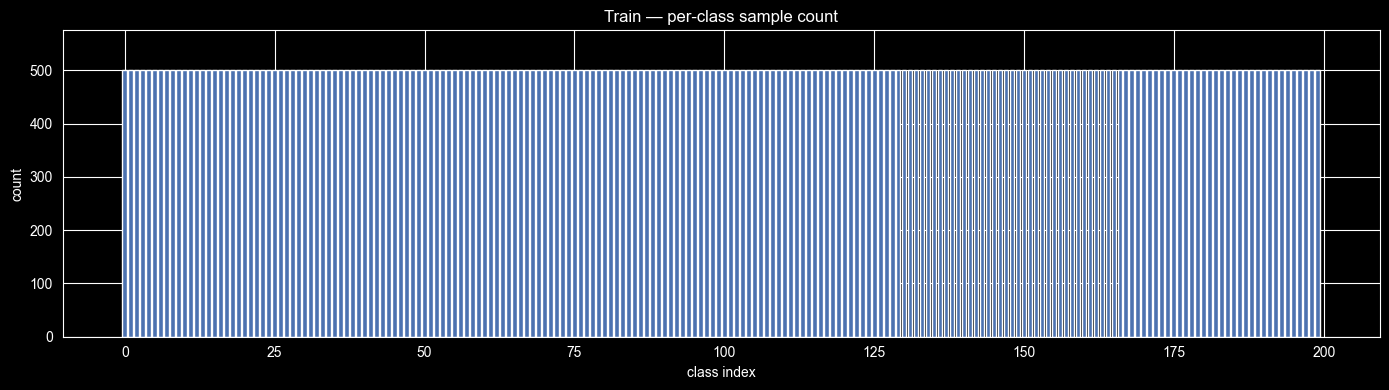

Train: min=500, max=500, mean=500.0, std=0.000


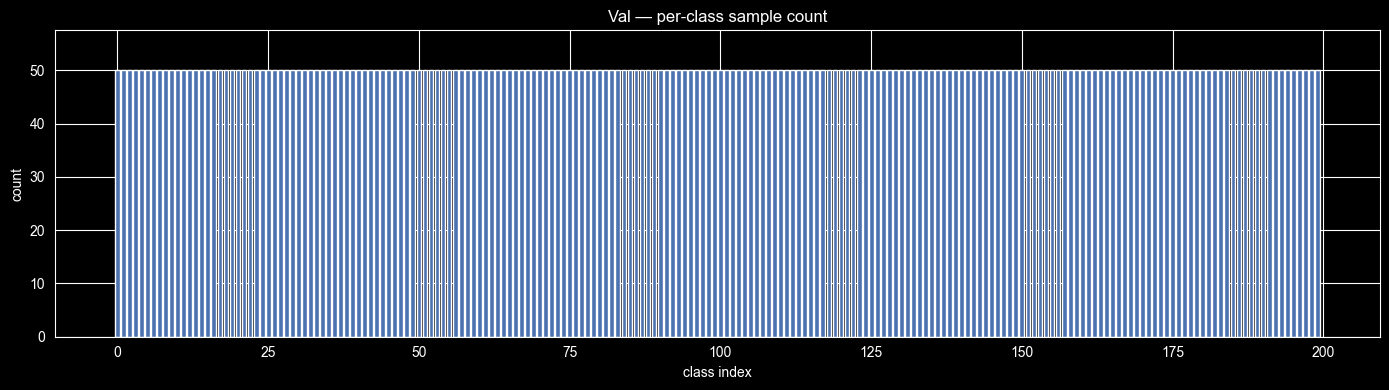

Val: min=50, max=50, mean=50.0, std=0.000
Train: size distribution (top 5, n=3000 sampled): [((64, 64), 3000)]
Train: color mode counts: {'RGB': 2950, 'L': 50}
Train: 50/3000 sampled images (1.67%) are NOT plain RGB — make sure your loader does .convert('RGB').


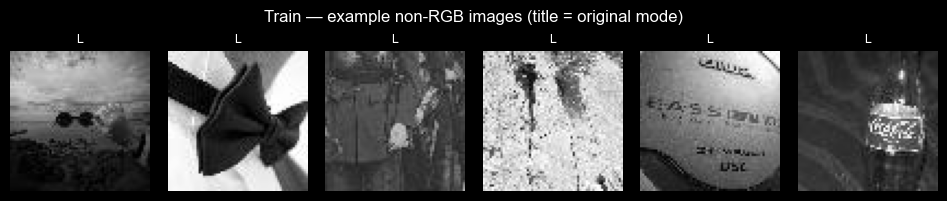

Test: size distribution (top 5, n=3000 sampled): [((64, 64), 3000)]
Test: color mode counts: {'RGB': 2950, 'L': 50}
Test: 50/3000 sampled images (1.67%) are NOT plain RGB — make sure your loader does .convert('RGB').


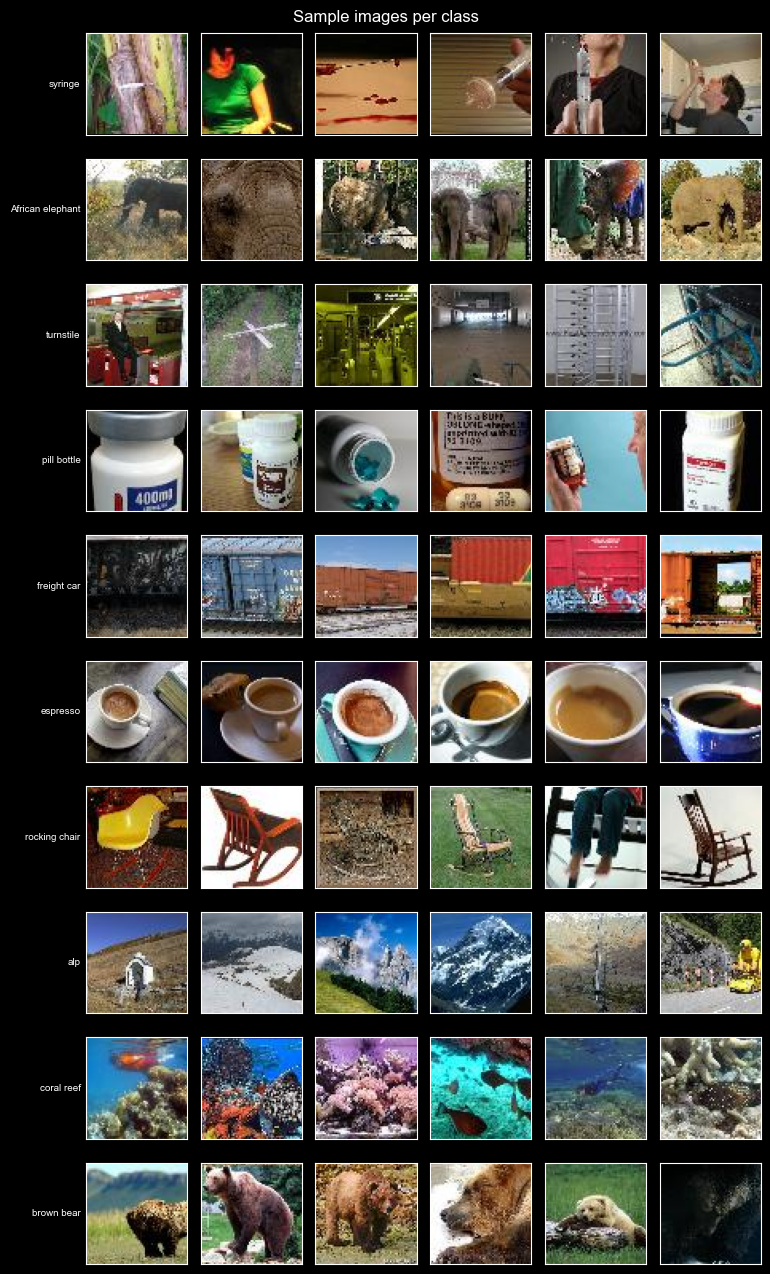

Train channel mean (RGB), n=2000 images: [0.47812355 0.44873486 0.39772383]
Train channel std  (RGB), n=2000 images: [0.27466388 0.26711452 0.27946891]


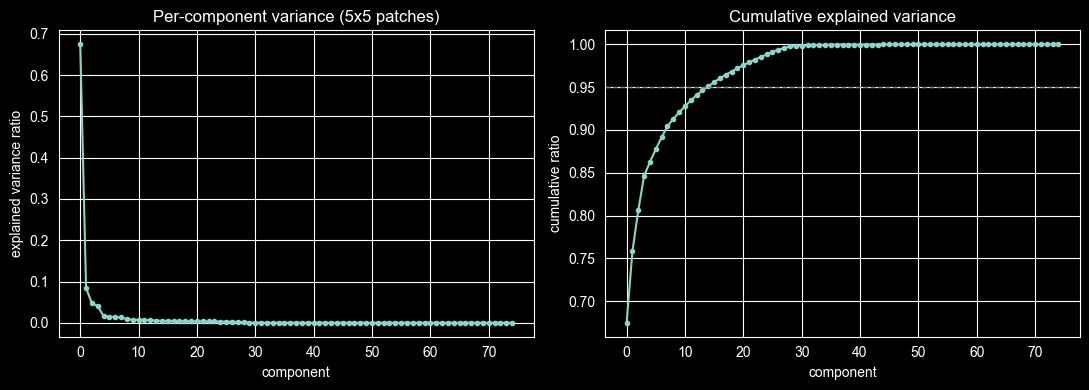

Components needed for 95% variance: 15 / 75


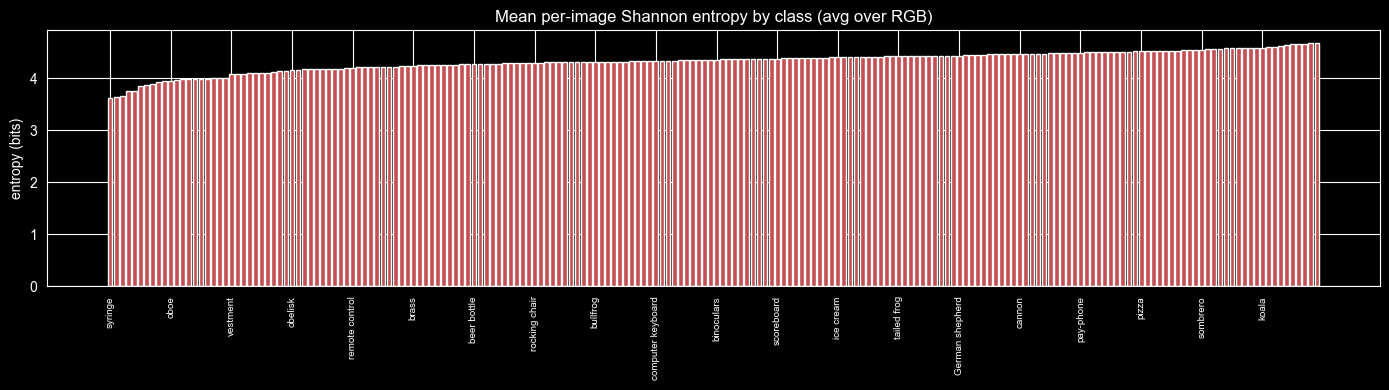

Entropy range across classes: 3.62 - 4.68 bits (spread: 1.06)


In [4]:
"""
Tiny ImageNet Exploratory Data Analysis
-----------------------------------------

Figures save to ./eda_outputs/ as PNGs.
"""

import os
from collections import Counter

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

OUT_DIR = "eda_outputs"
os.makedirs(OUT_DIR, exist_ok=True)


# ---------------------------------------------------------------------------
# Build class index + sample lists directly from the extracted directory.
# ---------------------------------------------------------------------------
def load_wnids(extract_dir):
    with open(os.path.join(extract_dir, "wnids.txt")) as f:
        wnids = [line.strip() for line in f if line.strip()]
    wnid_to_idx = {w: i for i, w in enumerate(wnids)}
    return wnids, wnid_to_idx


def load_class_names(extract_dir, wnids):
    """words.txt covers the full ~82k-entry WordNet noun hierarchy; filter to
    just the 200 wnids this dataset uses, keeping the first synonym as the
    display name."""
    names = {}
    with open(os.path.join(extract_dir, "words.txt"), encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) == 2:
                names[parts[0]] = parts[1].split(",")[0].strip()
    return [names.get(w, w) for w in wnids]


def list_train_samples(extract_dir, wnids, wnid_to_idx):
    samples = []
    for w in wnids:
        img_dir = os.path.join(extract_dir, "train", w, "images")
        for fname in sorted(os.listdir(img_dir)):
            if fname.lower().endswith((".jpeg", ".jpg")):
                samples.append((os.path.join(img_dir, fname), wnid_to_idx[w]))
    return samples


def list_val_samples(extract_dir, wnid_to_idx):
    samples = []
    ann_path = os.path.join(extract_dir, "val", "val_annotations.txt")
    img_dir = os.path.join(extract_dir, "val", "images")
    with open(ann_path) as f:
        for line in f:
            parts = line.strip().split("\t")
            fname, wnid = parts[0], parts[1]
            samples.append((os.path.join(img_dir, fname), wnid_to_idx[wnid]))
    return samples


def list_test_paths(extract_dir):
    img_dir = os.path.join(extract_dir, "test", "images")
    return [os.path.join(img_dir, f) for f in sorted(os.listdir(img_dir))
            if f.lower().endswith((".jpeg", ".jpg"))]


def _load_rgb_array(path):
    with Image.open(path) as img:
        return np.array(img.convert("RGB"))


# ---------------------------------------------------------------------------
# 1. Basic info
# ---------------------------------------------------------------------------
def basic_info(train_samples, val_samples, test_paths, classes):
    print(f"Train samples: {len(train_samples)}")
    print(f"Val samples:   {len(val_samples)}")
    print(f"Test samples:  {len(test_paths)} (unlabeled)")
    print(f"Num classes:   {len(classes)}")
    img0 = _load_rgb_array(train_samples[0][0])
    print(f"Example image shape (after .convert('RGB')): {img0.shape}")


# ---------------------------------------------------------------------------
# 2. Class balance. Train (500/class) and val (50/class) are balanced by
#    construction
# ---------------------------------------------------------------------------
def class_distribution(samples, classes, title, fname):
    labels = [lbl for _, lbl in samples]
    counts = Counter(labels)
    n_classes = len(classes)
    counts_sorted = [counts.get(i, 0) for i in range(n_classes)]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(n_classes), counts_sorted, color="#4C72B0")
    ax.set_title(f"{title} — per-class sample count")
    ax.set_xlabel("class index")
    ax.set_ylabel("count")
    ax.set_ylim(0, max(counts_sorted) * 1.15)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=150)
    plt.show()
    print(f"{title}: min={min(counts_sorted)}, max={max(counts_sorted)}, "
          f"mean={np.mean(counts_sorted):.1f}, std={np.std(counts_sorted):.3f}")


# ---------------------------------------------------------------------------
# 3. Image size + color-mode check -- the standout Tiny ImageNet-specific
#    diagnostic. Confirms 64x64 holds everywhere and quantifies the
#    grayscale/CMYK fraction instead of assuming everything is clean RGB.
# ---------------------------------------------------------------------------
def image_mode_check(samples_or_paths, title, max_images=3000, seed=0):
    rng = np.random.default_rng(seed)
    paths = [s[0] if isinstance(s, tuple) else s for s in samples_or_paths]
    idxs = rng.choice(len(paths), size=min(max_images, len(paths)), replace=False)
    modes = Counter()
    sizes = Counter()
    non_rgb_examples = []
    for i in idxs:
        with Image.open(paths[i]) as img:
            modes[img.mode] += 1
            sizes[img.size] += 1
            if img.mode != "RGB" and len(non_rgb_examples) < 6:
                non_rgb_examples.append(paths[i])
    print(f"{title}: size distribution (top 5, n={len(idxs)} sampled): {sizes.most_common(5)}")
    print(f"{title}: color mode counts: {dict(modes)}")
    n_non_rgb = sum(v for k, v in modes.items() if k != "RGB")
    pct = 100 * n_non_rgb / len(idxs)
    print(f"{title}: {n_non_rgb}/{len(idxs)} sampled images ({pct:.2f}%) are NOT plain RGB — "
          f"make sure your loader does .convert('RGB').")
    return modes, sizes, non_rgb_examples


def show_non_rgb_examples(paths, title, max_show=6):
    if not paths:
        print(f"{title}: no non-RGB examples found in the sample.")
        return
    n = min(len(paths), max_show)
    fig, axes = plt.subplots(1, n, figsize=(n * 1.6, 2))
    if n == 1:
        axes = [axes]
    for ax, p in zip(axes, paths[:n]):
        with Image.open(p) as img:
            mode = img.mode
            ax.imshow(img.convert("RGB"))
        ax.set_title(mode, fontsize=9)
        ax.axis("off")
    plt.suptitle(f"{title} — example non-RGB images (title = original mode)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "non_rgb_examples.png"), dpi=150)
    plt.show()


# ---------------------------------------------------------------------------
# 4. Sample grid
# ---------------------------------------------------------------------------
def sample_grid(samples, classes, n_classes=10, per_class=6, seed=0):
    rng = np.random.default_rng(seed)
    labels = np.array([lbl for _, lbl in samples])
    paths = [p for p, _ in samples]
    class_ids = rng.choice(len(classes), size=n_classes, replace=False)
    fig, axes = plt.subplots(n_classes, per_class, figsize=(per_class * 1.3, n_classes * 1.3))
    if n_classes == 1:
        axes = axes[None, :]
    for row, cid in enumerate(class_ids):
        idxs = np.where(labels == cid)[0]
        chosen = rng.choice(idxs, size=min(per_class, len(idxs)), replace=False)
        for col in range(per_class):
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            if col < len(chosen):
                with Image.open(paths[chosen[col]]) as img:
                    axes[row, col].imshow(img.convert("RGB"))
            if col == 0:
                axes[row, col].set_ylabel(classes[cid], rotation=0,
                                           ha="right", va="center", fontsize=7)
    plt.suptitle("Sample images per class")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "sample_grid.png"), dpi=150)
    plt.show()


# ---------------------------------------------------------------------------
# 5. Per-channel pixel statistics
# ---------------------------------------------------------------------------
def pixel_stats(samples, name, max_images=2000, seed=0):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(samples), size=min(max_images, len(samples)), replace=False)
    pixel_sum = np.zeros(3, dtype=np.float64)
    pixel_sq_sum = np.zeros(3, dtype=np.float64)
    pixel_count = 0
    for i in idxs:
        arr = _load_rgb_array(samples[i][0]).astype(np.float64) / 255.0
        pixel_sum += arr.sum(axis=(0, 1))
        pixel_sq_sum += (arr ** 2).sum(axis=(0, 1))
        pixel_count += arr.shape[0] * arr.shape[1]
    mean = pixel_sum / pixel_count
    var = pixel_sq_sum / pixel_count - mean ** 2
    std = np.sqrt(np.clip(var, 0, None))
    print(f"{name} channel mean (RGB), n={len(idxs)} images: {mean}")
    print(f"{name} channel std  (RGB), n={len(idxs)} images: {std}")
    return mean, std


# ---------------------------------------------------------------------------
# 6. Patch-level PCA eigenvalue spectrum — relevant to the PCA-hybrid
#    ResNet+ViT pipeline's PCA stage. Images are natively a fixed 64x64
#    here, so no resize is needed before extracting patches (unlike Flowers102).
# ---------------------------------------------------------------------------
def patch_pca_spectrum(samples, patch_size=5, n_images=1200, stride=2, seed=0):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(samples), size=min(n_images, len(samples)), replace=False)
    patches = []
    for i in idxs:
        arr = _load_rgb_array(samples[i][0]).astype(np.float32) / 255.0
        H, W, C = arr.shape
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                patches.append(arr[y:y + patch_size, x:x + patch_size, :].reshape(-1))
    patches = np.stack(patches)
    patches = patches - patches.mean(axis=0, keepdims=True)
    cov = np.cov(patches, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)[::-1]
    eigvals = np.clip(eigvals, 0, None)
    explained = eigvals / eigvals.sum()
    cum_explained = np.cumsum(explained)

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(explained, marker="o", ms=3)
    ax[0].set_title(f"Per-component variance ({patch_size}x{patch_size} patches)")
    ax[0].set_xlabel("component")
    ax[0].set_ylabel("explained variance ratio")
    ax[1].plot(cum_explained, marker="o", ms=3)
    ax[1].axhline(0.95, color="gray", linestyle="--", linewidth=1)
    ax[1].set_title("Cumulative explained variance")
    ax[1].set_xlabel("component")
    ax[1].set_ylabel("cumulative ratio")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "patch_pca_spectrum.png"), dpi=150)
    plt.show()

    n95 = int(np.searchsorted(cum_explained, 0.95) + 1)
    print(f"Components needed for 95% variance: {n95} / {patches.shape[1]}")
    return eigvals


# ---------------------------------------------------------------------------
# 7. Per-channel Shannon entropy by class
# ---------------------------------------------------------------------------
def channel_entropy(img, bins=32):
    ents = []
    for c in range(img.shape[2]):
        hist, _ = np.histogram(img[:, :, c], bins=bins, range=(0, 255))
        prob = hist / hist.sum()
        prob = prob[prob > 0]
        ents.append(-np.sum(prob * np.log2(prob)))
    return ents


def entropy_by_class(samples, classes, n_per_class=15, seed=0):
    rng = np.random.default_rng(seed)
    labels = np.array([lbl for _, lbl in samples])
    paths = [p for p, _ in samples]
    n_classes = len(classes)
    class_mean_entropy = []
    for c in range(n_classes):
        idxs = np.where(labels == c)[0]
        if len(idxs) == 0:
            class_mean_entropy.append([np.nan, np.nan, np.nan])
            continue
        chosen = rng.choice(idxs, size=min(n_per_class, len(idxs)), replace=False)
        ents = [channel_entropy(_load_rgb_array(paths[i])) for i in chosen]
        class_mean_entropy.append(np.mean(ents, axis=0))
    class_mean_entropy = np.array(class_mean_entropy)

    order = np.argsort(class_mean_entropy.mean(axis=1))
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(n_classes), class_mean_entropy.mean(axis=1)[order], color="#C44E52")
    step = max(1, n_classes // 20)
    ax.set_xticks(range(0, n_classes, step))
    ax.set_xticklabels([classes[order[i]] for i in range(0, n_classes, step)],
                        rotation=90, fontsize=7)
    ax.set_title("Mean per-image Shannon entropy by class (avg over RGB)")
    ax.set_ylabel("entropy (bits)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "entropy_by_class.png"), dpi=150)
    plt.show()

    valid = ~np.isnan(class_mean_entropy.mean(axis=1))
    m = class_mean_entropy.mean(axis=1)[valid]
    print(f"Entropy range across classes: {m.min():.2f} - {m.max():.2f} bits "
          f"(spread: {m.max() - m.min():.2f})")
    return class_mean_entropy


# ---------------------------------------------------------------------------
# Run everything
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    # Reuses EXTRACT_DIR from your download/extract snippet.
    DATA_ROOT = "./data"
    EXTRACT_DIR = os.path.join(DATA_ROOT, "tiny-imagenet-200")

    wnids, wnid_to_idx = load_wnids(EXTRACT_DIR)
    classes = load_class_names(EXTRACT_DIR, wnids)

    train_samples = list_train_samples(EXTRACT_DIR, wnids, wnid_to_idx)
    val_samples = list_val_samples(EXTRACT_DIR, wnid_to_idx)
    test_paths = list_test_paths(EXTRACT_DIR)

    basic_info(train_samples, val_samples, test_paths, classes)
    class_distribution(train_samples, classes, "Train", "class_dist_train.png")
    class_distribution(val_samples, classes, "Val", "class_dist_val.png")
    _, _, non_rgb = image_mode_check(train_samples, "Train")
    show_non_rgb_examples(non_rgb, "Train")
    image_mode_check(test_paths, "Test")
    sample_grid(train_samples, classes)
    pixel_stats(train_samples, "Train")
    patch_pca_spectrum(train_samples, patch_size=5)
    entropy_by_class(train_samples, classes)